In [87]:
# ==============================================================
# CELL 1 – Imports, Hardware Setup, Drive Mount & REPRODUCIBILITY
# ==============================================================
import sys, os, random
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

# --- REPRODUCIBILITY SEED ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
print("Seed globale impostato a 42 per la riproducibilità.")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device}')
print(f'PyTorch version: {torch.__version__}')

Seed globale impostato a 42 per la riproducibilità.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device in use: cpu
PyTorch version: 2.10.0+cpu


In [88]:
import numpy as np
import h5py
import scipy.io as sio

# 1. Path del file .mat processato
PATH_MAT = '/content/drive/MyDrive/Tesi_Raman/Datasets/IBD_Dataset_500pt.mat'

print(f'Caricamento dati processati da {PATH_MAT}...')

try:
    with h5py.File(PATH_MAT, 'r') as f:
        print("Variabili trovate nel .mat:", list(f.keys()))

        X_data = np.array(f['X_processed'])
        Y_data = np.array(f['labels_binary']).flatten().astype(np.int64)

        if 'mask_binary' in f.keys():
            mask_binary = np.array(f['mask_binary']).flatten().astype(bool)
            X_data = X_data[mask_binary]
            Y_data = Y_data[mask_binary]

except (OSError, NotImplementedError):
    data = sio.loadmat(PATH_MAT)
    print("Variabili trovate nel .mat:", [k for k in data.keys() if not k.startswith('__')])

    X_data = data['X_processed'].astype(np.float32)
    Y_data = data['labels_binary'].flatten().astype(np.int64)

    if 'mask_binary' in data:
        mask_binary = data['mask_binary'].flatten().astype(bool)
        X_data = X_data[mask_binary]
        Y_data = Y_data[mask_binary]

# Fix shape se serve
if X_data.shape[0] == 500 and X_data.shape[1] == len(Y_data):
    X_data = X_data.T

X_data = X_data.astype(np.float32)

N, L = X_data.shape
print("-" * 40)
print(f'Spettri usabili : {N}')
print(f'Punti spettrali : {L}')
print(f'HC (0)          : {(Y_data==0).sum()}')
print(f'IBD (1)         : {(Y_data==1).sum()}')
print(f'X shape         : {X_data.shape}')
print(f'Y shape         : {Y_data.shape}')


Caricamento dati processati da /content/drive/MyDrive/Tesi_Raman/Datasets/IBD_Dataset_500pt.mat...
Variabili trovate nel .mat: ['#refs#', '#subsystem#', 'X_processed', 'asse_target', 'labels_binary', 'labels_detail']
----------------------------------------
Spettri usabili : 228
Punti spettrali : 500
HC (0)          : 93
IBD (1)         : 135
X shape         : (228, 500)
Y shape         : (228,)


In [89]:
# ==============================================================
# CELL 3 - Build HybridCNNTransformer & Load Foundation Weights
# ==============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridCNNTransformer(nn.Module):
    def __init__(self, input_length=500, n_classes=2, d_model=64, nhead=4, num_layers=3, dropout=0.1):
        super(HybridCNNTransformer, self).__init__()

        # 1. CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU()
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            seq_len_after_cnn = self.cnn(dummy).shape[-1]

        # 2. Transformer Components
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len_after_cnn + 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 3. Classificatore finale
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        features = self.cnn(x)
        features = features.transpose(1, 2)

        B = features.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, features), dim=1)
        x = x + self.pos_embedding

        x = self.transformer(x)
        cls_out = x[:, 0, :]
        out = self.classifier(cls_out)
        return out

class HybridMAE(nn.Module):
    def __init__(self, encoder: HybridCNNTransformer, mask_ratio=0.5):
        super().__init__()
        self.encoder = encoder
        self.mask_ratio = mask_ratio
        d_model = encoder.pos_embedding.shape[-1]
        self.mask_token = nn.Parameter(torch.zeros(1, 1, d_model))

        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, batch_first=True, activation="gelu")
        self.decoder_transformer = nn.TransformerEncoder(decoder_layer, num_layers=2)
        self.decoder_head = nn.Sequential(
            nn.ConvTranspose1d(d_model, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.ConvTranspose1d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.ConvTranspose1d(16, 1, kernel_size=7, stride=2, padding=3, output_padding=1)
        )

    def forward(self, x):
        pass # Forward non necessario per il fine-tuning, ci serve solo caricare i pesi dell'encoder

SPECTRA_SIZE = 500
PATH_PRETRAINED = '/content/drive/MyDrive/RamanMAE_Project/saved_models/hybrid_mae_pretrained.pth'

print("Building HybridCNNTransformer & HybridMAE...")
base_encoder = HybridCNNTransformer(input_length=SPECTRA_SIZE, d_model=64)
foundation_model = HybridMAE(base_encoder, mask_ratio=0.75).to(device)

try:
    foundation_model.load_state_dict(torch.load(PATH_PRETRAINED, map_location=device))
    print(f'\u2705 Pre-trained weights loaded from: {PATH_PRETRAINED}')
except Exception as e:
    print(f'\u26a0\ufe0f Impossibile caricare i pesi. Errore: {e}\nUseremo il modello non pre-addestrato per ora.')

# Estraiamo l'encoder per la classificazione
pretrained_encoder = foundation_model.encoder

Building HybridCNNTransformer & HybridMAE...
✅ Pre-trained weights loaded from: /content/drive/MyDrive/RamanMAE_Project/saved_models/hybrid_mae_pretrained.pth


In [90]:
# ==============================================================
# CELL 4 – Classification Model Architecture
# ==============================================================

class HybridClassifierWrapper(nn.Module):
    """
    Wrapper per il HybridCNNTransformer per permettere il freeze/unfreeze
    della CNN e del Transformer durante le fasi di LP-FT.
    """
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder # E' un'istanza di HybridCNNTransformer

    def forward(self, x):
        # Il forward dell'encoder restituisce già i logits poiché ha self.classifier
        return self.encoder(x)

    def freeze_encoder(self):
        """Congela CNN e Transformer, lascia addestrabile solo il classificatore."""
        for param in self.encoder.cnn.parameters():
            param.requires_grad = False
        for param in self.encoder.transformer.parameters():
            param.requires_grad = False
        self.encoder.cls_token.requires_grad = False
        self.encoder.pos_embedding.requires_grad = False

        for param in self.encoder.classifier.parameters():
            param.requires_grad = True

    def unfreeze_encoder(self):
        """Scongela tutto per il Full Fine-Tuning."""
        for param in self.parameters():
            param.requires_grad = True

# Quick diagnostic print
test_clf = HybridClassifierWrapper(pretrained_encoder).to(device)
test_clf.freeze_encoder()
print(f"Trainable parameters in Stage 1 (Head only): {sum(p.numel() for p in test_clf.parameters() if p.requires_grad):,}")
test_clf.unfreeze_encoder()
print(f"Trainable parameters in Stage 2 (Full Model): {sum(p.numel() for p in test_clf.parameters() if p.requires_grad):,}")

Trainable parameters in Stage 1 (Head only): 8,706
Trainable parameters in Stage 2 (Full Model): 171,970


In [91]:
# ==============================================================
# CELL 5 – Train / Val / Test Split (70-15-15)
# ==============================================================
from sklearn.model_selection import train_test_split

# ---> CAMBIA QUESTO VALORE PER PROVARE SPLIT DIVERSI <---
SEED = 42 # Prova con 0, 123, 999, o toglilo (None) per averlo sempre diverso

# Splitting Data into 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, Y_data, test_size=0.30, random_state=SEED, stratify=Y_data
)

# Splitting Temp into 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples (HC: {(y_train==0).sum()}, IBD: {(y_train==1).sum()})")
print(f"Val set:   {X_val.shape[0]} samples (HC: {(y_val==0).sum()}, IBD: {(y_val==1).sum()})")
print(f"Test set:  {X_test.shape[0]} samples (HC: {(y_test==0).sum()}, IBD: {(y_test==1).sum()})")

Train set: 159 samples (HC: 65, IBD: 94)
Val set:   34 samples (HC: 14, IBD: 20)
Test set:  35 samples (HC: 14, IBD: 21)


In [92]:
# ==============================================================
# CELL 6 – LP-FT FINE-TUNING (Train / Val)
# ==============================================================
import time
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import numpy as np
import copy

# Hyperparameters
LP_EPOCHS = 30
FT_EPOCHS = 100   # Aumentato per permettere al modello di scendere di piu'
LP_LR = 1e-3
FT_LR = 5e-5
BATCH_SIZE = 16
PATIENCE = 25     # Aumentato per evitare stop prematuri

def eval_model(model, loader):
    model.eval()
    preds, labels, probs, losses = [], [], [], []
    criterion = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            probs.append(F.softmax(logits, dim=1)[:, 1].cpu())
            preds.append(logits.argmax(dim=1).cpu())
            labels.append(yb.cpu())
    return (torch.cat(preds).numpy(),
            torch.cat(labels).numpy(),
            torch.cat(probs).numpy(),
            np.mean(losses))

# DataLoaders
Xtr = torch.from_numpy(X_train).unsqueeze(1)
ytr = torch.from_numpy(y_train)
Xva = torch.from_numpy(X_val).unsqueeze(1)
yva = torch.from_numpy(y_val)

loader_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=BATCH_SIZE, shuffle=True)
loader_va = DataLoader(TensorDataset(Xva, yva), batch_size=BATCH_SIZE, shuffle=False)

# Model setup
model = HybridClassifierWrapper(copy.deepcopy(pretrained_encoder)).to(device)

# Class weights (GIA' PRESENTI!)
n_sano = (ytr == 0).sum().item()
n_ibd = (ytr == 1).sum().item()
weights = torch.tensor([1.0/n_sano if n_sano>0 else 0, 1.0/n_ibd if n_ibd>0 else 0], device=device)
weights = weights / weights.sum() * 2.0
criterion = torch.nn.CrossEntropyLoss(weight=weights)

history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": [], "val_auc": []}

# --- STAGE 1: LP ---
print("STAGE 1: Linear Probing")
model.freeze_encoder()
optimizer_lp = AdamW(model.encoder.classifier.parameters(), lr=LP_LR)

for epoch in range(LP_EPOCHS):
    model.train()
    total_loss = 0
    for Xb, yb in loader_tr:
        optimizer_lp.zero_grad()
        loss = criterion(model(Xb.to(device)), yb.to(device))
        loss.backward()
        optimizer_lp.step()
        total_loss += loss.item()

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    history["train_loss"].append(total_loss/len(loader_tr))
    history["val_loss"].append(val_loss)
    history["val_acc"].append(accuracy_score(labels_val, preds_val))
    history["val_f1"].append(f1_score(labels_val, preds_val, average="macro"))

# --- STAGE 2: FT ---
print("STAGE 2: Fine-Tuning (con Scheduler)")
model.unfreeze_encoder()
optimizer_ft = AdamW(model.parameters(), lr=FT_LR)
# Inseriamo lo scheduler: dimezza il LR se la val_loss non migliora per 7 epoche
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=7)

best_f1 = 0
no_improve = 0
best_state = None

for epoch in range(FT_EPOCHS):
    model.train()
    total_loss = 0
    for Xb, yb in loader_tr:
        optimizer_ft.zero_grad()
        loss = criterion(model(Xb.to(device)), yb.to(device))
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    history["train_loss"].append(total_loss/len(loader_tr))
    history["val_loss"].append(val_loss)
    history["val_acc"].append(accuracy_score(labels_val, preds_val))
    history["val_f1"].append(val_f1)

    # Step dello scheduler sulla val_loss
    scheduler_ft.step(val_loss)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
print("Training Completed. Best Val F1:", best_f1)

STAGE 1: Linear Probing
STAGE 2: Fine-Tuning (con Scheduler)
Early stopping at epoch 80
Training Completed. Best Val F1: 0.9392857142857143


In [93]:
# ============================================================
# CELL 7 — Test Set Evaluation
# ============================================================
Xte = torch.from_numpy(X_test).unsqueeze(1)
yte = torch.from_numpy(y_test)
loader_te = DataLoader(TensorDataset(Xte, yte), batch_size=BATCH_SIZE, shuffle=False)

preds_test, labels_test, probs_test, test_loss = eval_model(model, loader_te)

print("Test Accuracy:", accuracy_score(labels_test, preds_test))
print("Test Macro-F1:", f1_score(labels_test, preds_test, average="macro"))
print("Test ROC-AUC:", roc_auc_score(labels_test, probs_test) if len(np.unique(labels_test)) > 1 else "N/A")

Test Accuracy: 0.7714285714285715
Test Macro-F1: 0.7697368421052632
Test ROC-AUC: 0.8809523809523809


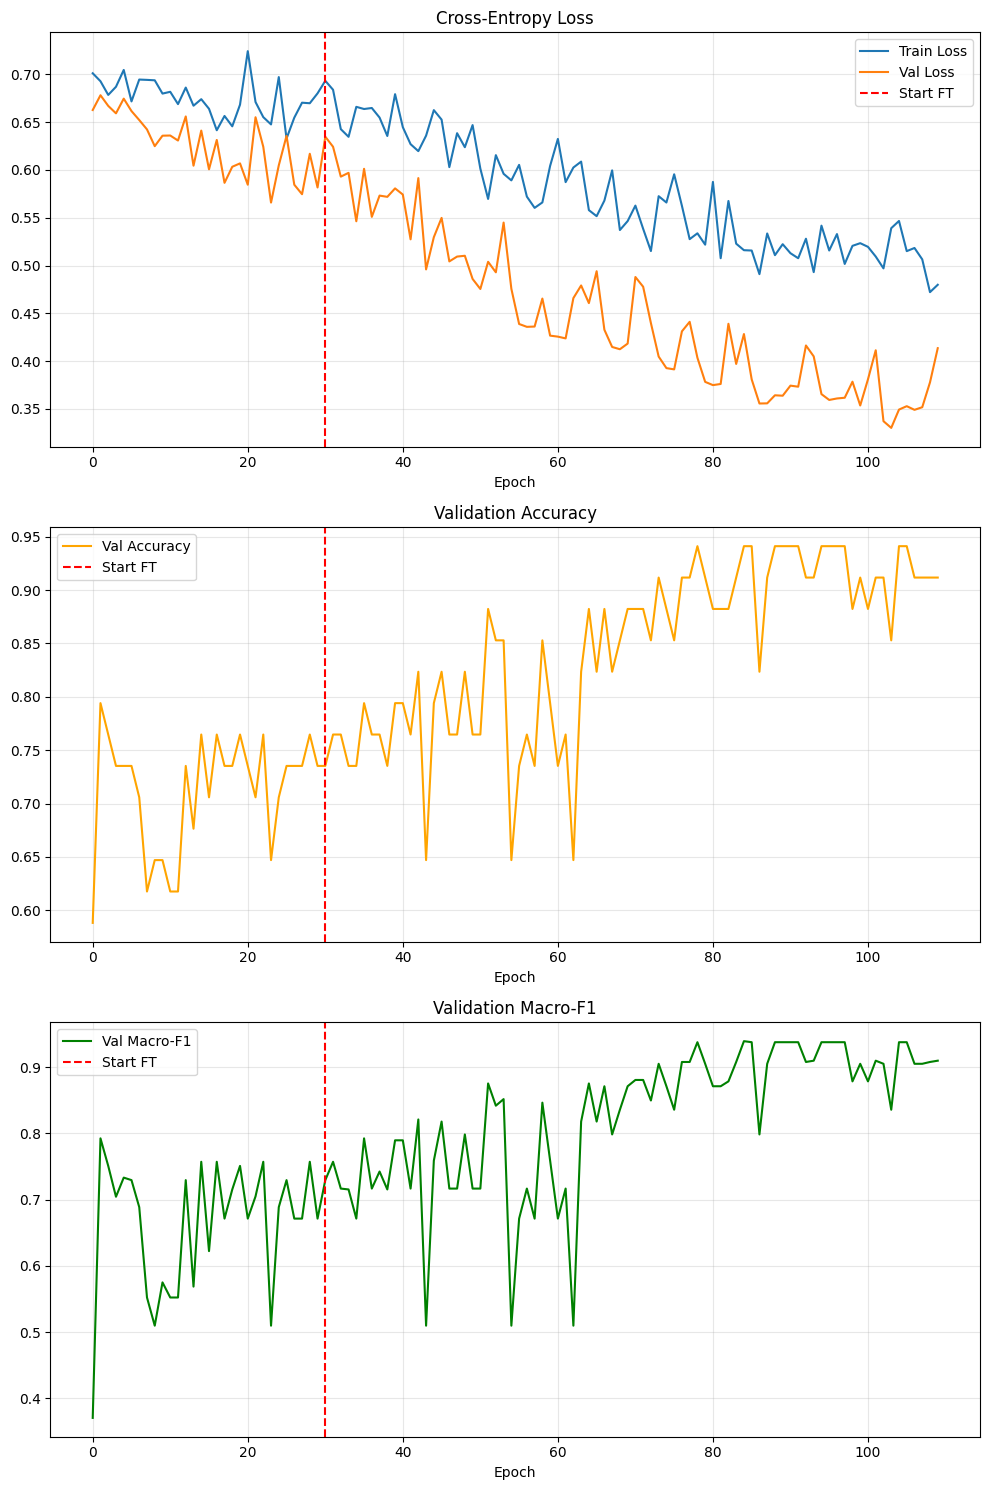

In [94]:
# ============================================================
# CELL 8 — Training Curves
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# --- Loss ---
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy ---
axes[1].plot(history["val_acc"], label="Val Accuracy", color='orange')
axes[1].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- F1 Score ---
axes[2].plot(history["val_f1"], label="Val Macro-F1", color='green')
axes[2].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[2].set_title("Validation Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

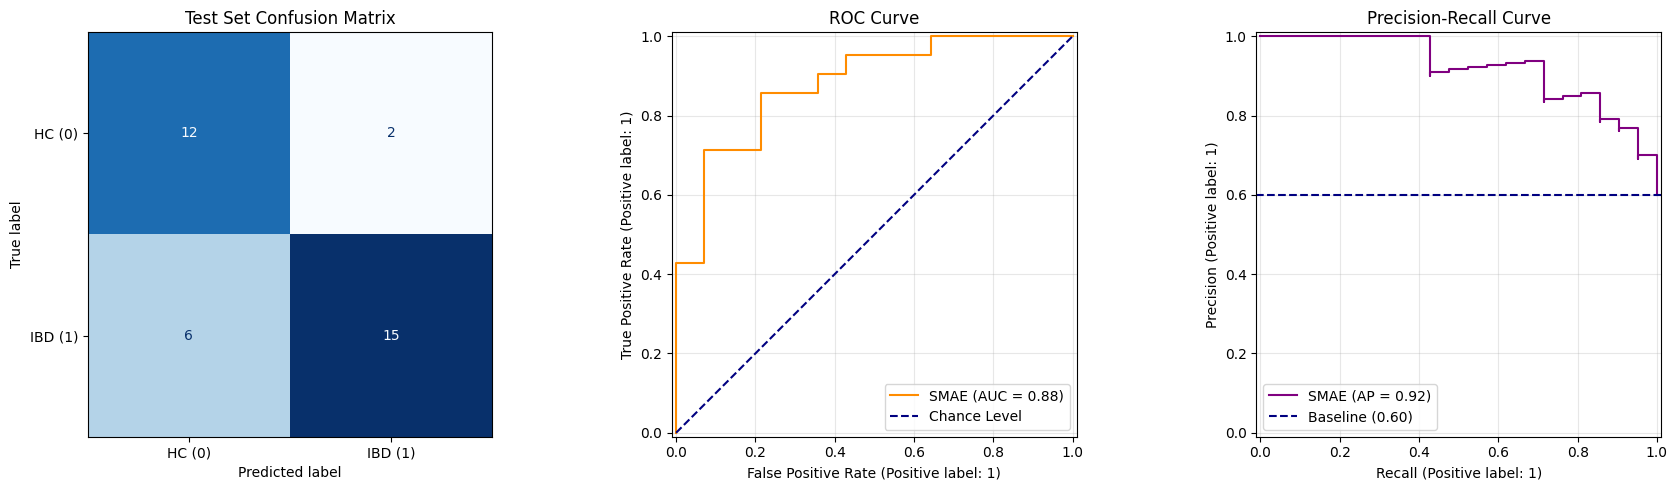


 GLOBAL CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

      HC (0)       0.67      0.86      0.75        14
     IBD (1)       0.88      0.71      0.79        21

    accuracy                           0.77        35
   macro avg       0.77      0.79      0.77        35
weighted avg       0.80      0.77      0.77        35



In [95]:
# ============================================================
# CELL 9 — Clinical Evaluation & Scientific Plotting
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay,
                             PrecisionRecallDisplay)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(labels_test, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC (0)', 'IBD (1)'])
disp.plot(cmap='Blues', ax=ax1, colorbar=False)
ax1.set_title("Test Set Confusion Matrix")

# 2. ROC Curve
RocCurveDisplay.from_predictions(labels_test, probs_test, ax=ax2, color='darkorange', name='SMAE')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Chance Level')
ax2.set_title("ROC Curve")
ax2.grid(alpha=0.3)
ax2.legend()

# 3. PR Curve
PrecisionRecallDisplay.from_predictions(labels_test, probs_test, ax=ax3, color='purple', name='SMAE')
baseline = sum(labels_test) / len(labels_test)
ax3.axhline(baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax3.set_title("Precision-Recall Curve")
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

print('\n' + '='*50)
print(' GLOBAL CLASSIFICATION REPORT (Test Set)')
print('='*50)
print(classification_report(labels_test, preds_test, target_names=['HC (0)', 'IBD (1)']))


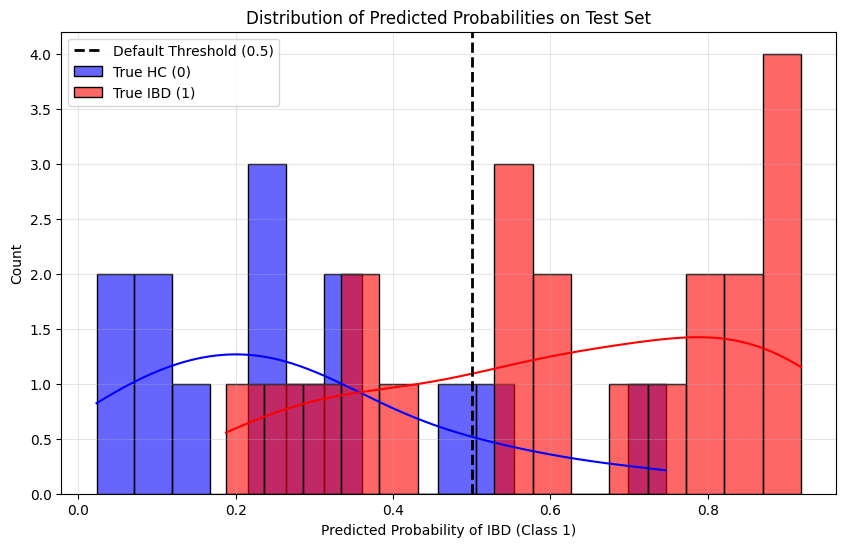

In [96]:
# ============================================================
# CELL 10 — Prediction Distribution (Histogram)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(probs_test[labels_test == 0], bins=15, color='blue', alpha=0.6, label='True HC (0)', kde=True)
sns.histplot(probs_test[labels_test == 1], bins=15, color='red', alpha=0.6, label='True IBD (1)', kde=True)
plt.axvline(0.5, color='k', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
plt.title('Distribution of Predicted Probabilities on Test Set')
plt.xlabel('Predicted Probability of IBD (Class 1)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==============================================================
# SUPPLEMENTARY: K-Fold CV & From Scratch Comparison
# ==============================================================

--- Inizio 5-Fold CV con Pre-Trained Model ---

Fold 1/5 (Pre-Trained)
Fold 1 Risultati - Acc: 0.7391, Macro-F1: 0.7386, AUC: 0.8090


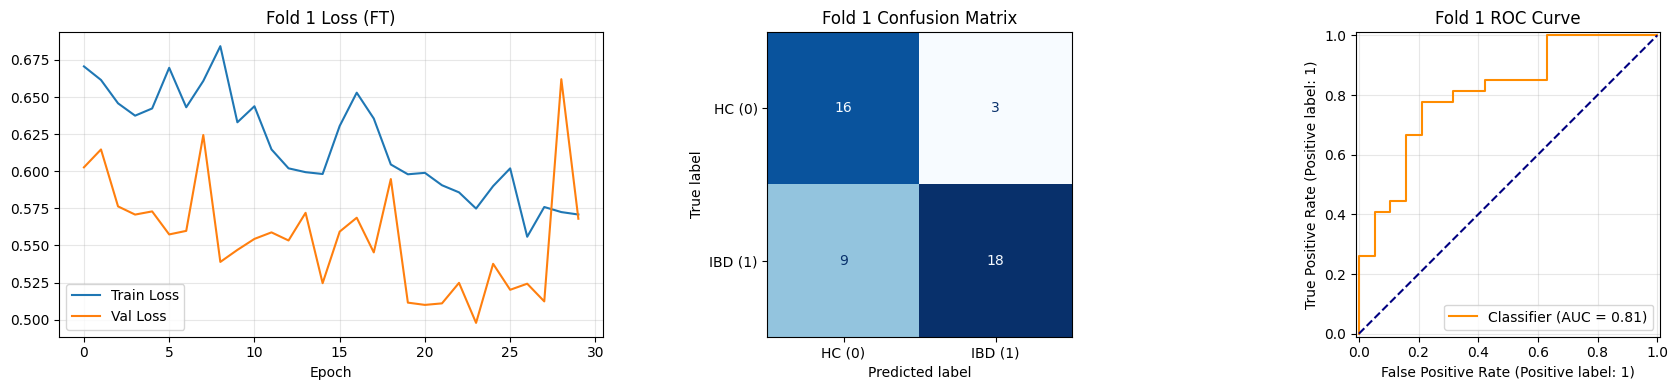


Fold 2/5 (Pre-Trained)
Fold 2 Risultati - Acc: 0.7826, Macro-F1: 0.7758, AUC: 0.7797


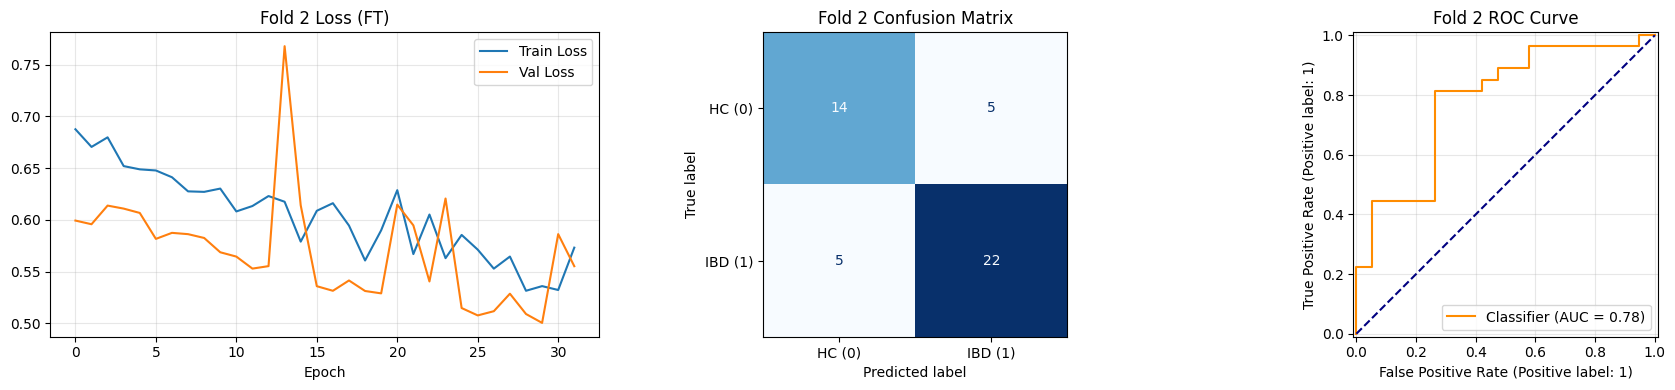


Fold 3/5 (Pre-Trained)
Fold 3 Risultati - Acc: 0.8043, Macro-F1: 0.8035, AUC: 0.8421


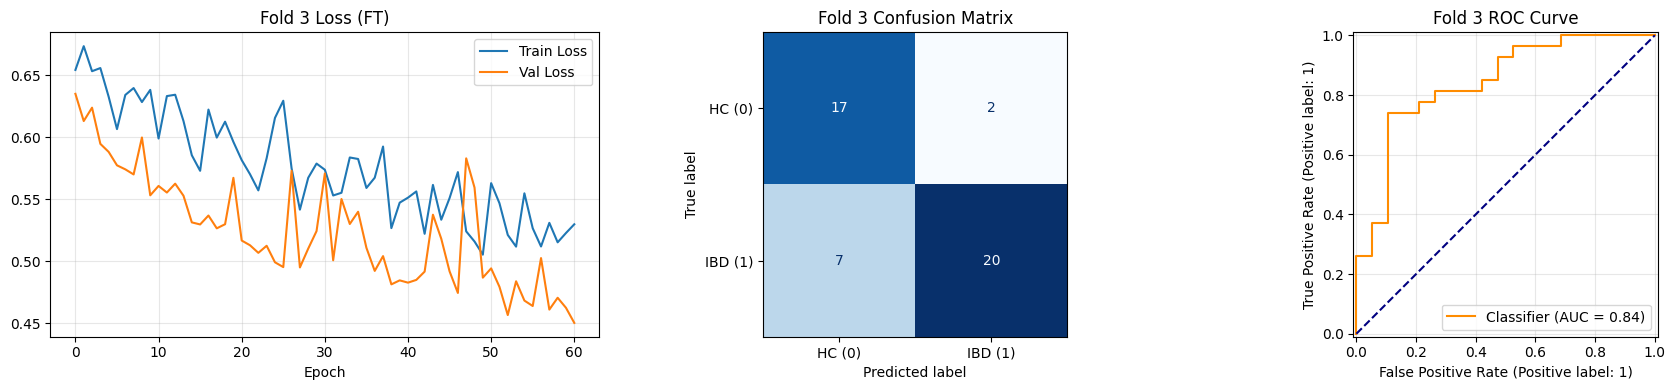


Fold 4/5 (Pre-Trained)
Fold 4 Risultati - Acc: 0.8444, Macro-F1: 0.8364, AUC: 0.8498


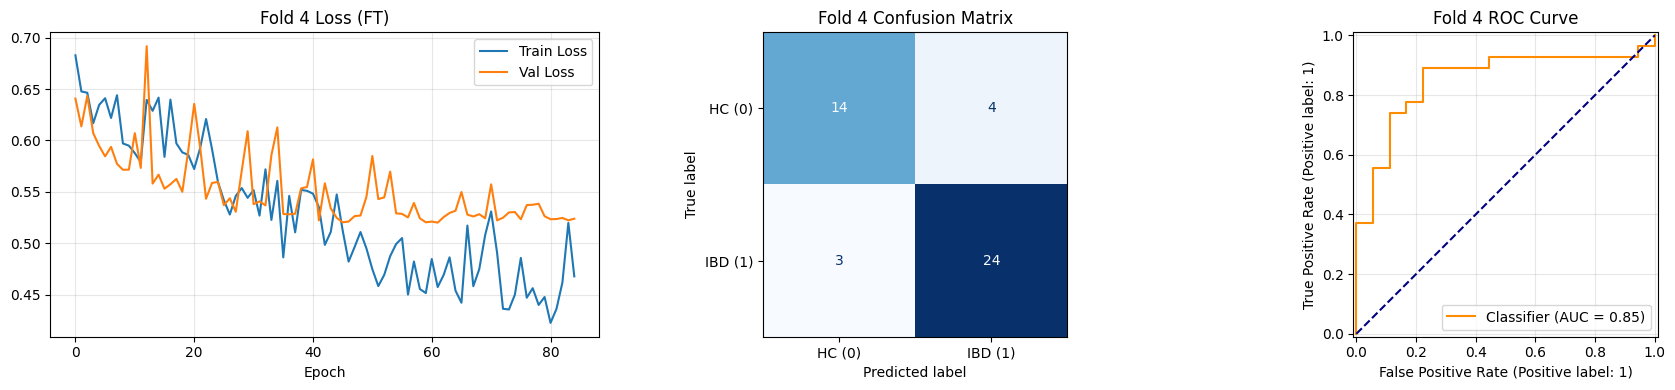


Fold 5/5 (Pre-Trained)
Fold 5 Risultati - Acc: 0.8000, Macro-F1: 0.7896, AUC: 0.7819


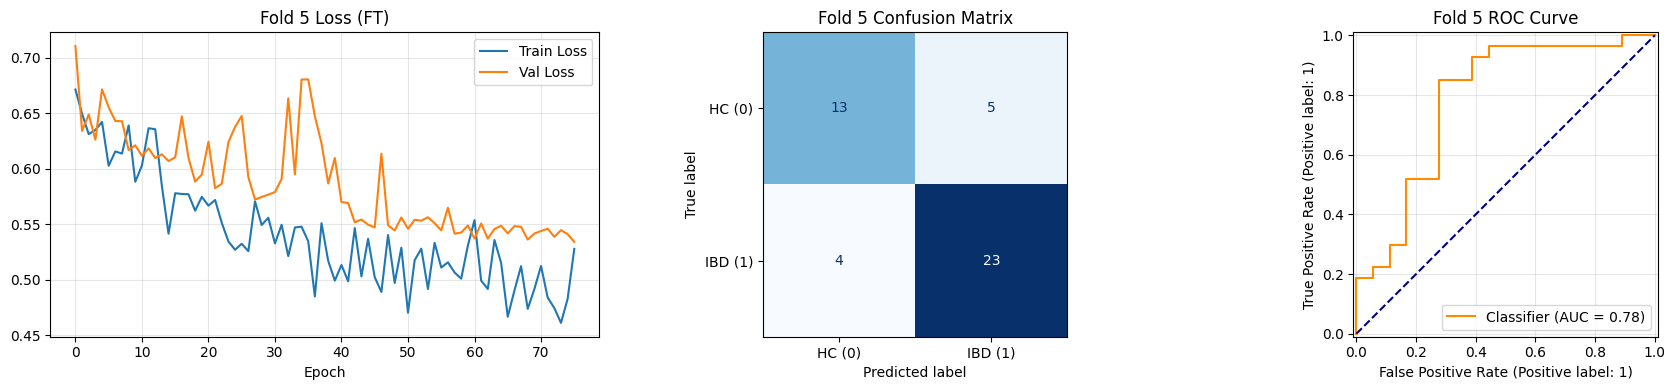


=== RISULTATI K-FOLD (PRE-TRAINED) ===
Accuracy: 0.7941 ± 0.0341
Macro-F1: 0.7888 ± 0.0321
ROC-AUC:  0.8125 ± 0.0293


In [97]:
# ==============================================================
# K-FOLD CROSS-VALIDATION (PRE-TRAINED MODEL)
# ==============================================================
from sklearn.model_selection import StratifiedKFold
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from torch.optim.lr_scheduler import ReduceLROnPlateau

K_FOLDS = 5
SEED = 42 # Fallback nel caso la cella 5 non sia stata eseguita
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

fold_metrics_pt = {'acc': [], 'f1': [], 'auc': []}

print(f"--- Inizio {K_FOLDS}-Fold CV con Pre-Trained Model ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, Y_data)):
    print(f"\n{'='*40}\nFold {fold+1}/{K_FOLDS} (Pre-Trained)\n{'='*40}")

    # Data
    Xtr_f = torch.from_numpy(X_data[train_idx]).unsqueeze(1).float()
    ytr_f = torch.from_numpy(Y_data[train_idx])
    Xva_f = torch.from_numpy(X_data[val_idx]).unsqueeze(1).float()
    yva_f = torch.from_numpy(Y_data[val_idx])

    loader_tr_f = DataLoader(TensorDataset(Xtr_f, ytr_f), batch_size=BATCH_SIZE, shuffle=True)
    loader_va_f = DataLoader(TensorDataset(Xva_f, yva_f), batch_size=BATCH_SIZE, shuffle=False)

    # Reset Model to Pre-Trained State
    model_cv = HybridClassifierWrapper(copy.deepcopy(pretrained_encoder)).to(device)

    # Class Weights
    ns = (ytr_f == 0).sum().item()
    ni = (ytr_f == 1).sum().item()
    w = torch.tensor([1.0/ns if ns>0 else 0, 1.0/ni if ni>0 else 0], device=device)
    criterion_cv = torch.nn.CrossEntropyLoss(weight=(w / w.sum() * 2.0))

    # LP
    model_cv.freeze_encoder()
    opt_lp = AdamW(model_cv.encoder.classifier.parameters(), lr=LP_LR)
    for epoch in range(15): # Ridotto per velocizzare la CV
        model_cv.train()
        for Xb, yb in loader_tr_f:
            opt_lp.zero_grad()
            loss = criterion_cv(model_cv(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_lp.step()

    # FT
    model_cv.unfreeze_encoder()
    opt_ft = AdamW(model_cv.parameters(), lr=FT_LR)
    scheduler_cv = ReduceLROnPlateau(opt_ft, mode='min', factor=0.5, patience=7)
    best_f1, no_improve, best_state = 0, 0, None

    fold_history = {"train_loss": [], "val_loss": []}

    for epoch in range(FT_EPOCHS):
        model_cv.train()
        train_loss = 0
        for Xb, yb in loader_tr_f:
            opt_ft.zero_grad()
            loss = criterion_cv(model_cv(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_ft.step()
            train_loss += loss.item()

        preds_v, labels_v, probs_v, val_loss = eval_model(model_cv, loader_va_f)
        v_f1 = f1_score(labels_v, preds_v, average="macro")

        fold_history["train_loss"].append(train_loss / len(loader_tr_f))
        fold_history["val_loss"].append(val_loss)

        # Scheduler step
        scheduler_cv.step(val_loss)

        if v_f1 > best_f1:
            best_f1 = v_f1
            best_state = copy.deepcopy(model_cv.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    # Evaluate Best
    model_cv.load_state_dict(best_state)
    preds_v, labels_v, probs_v, _ = eval_model(model_cv, loader_va_f)

    acc = accuracy_score(labels_v, preds_v)
    f1 = f1_score(labels_v, preds_v, average="macro")
    auc = roc_auc_score(labels_v, probs_v)

    fold_metrics_pt['acc'].append(acc)
    fold_metrics_pt['f1'].append(f1)
    fold_metrics_pt['auc'].append(auc)
    print(f"Fold {fold+1} Risultati - Acc: {acc:.4f}, Macro-F1: {f1:.4f}, AUC: {auc:.4f}")

    # --- PLOTTING PER FOLD ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    # 1. Loss Curve
    ax1.plot(fold_history["train_loss"], label="Train Loss")
    ax1.plot(fold_history["val_loss"], label="Val Loss")
    ax1.set_title(f"Fold {fold+1} Loss (FT)")
    ax1.set_xlabel("Epoch")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Confusion Matrix
    cm = confusion_matrix(labels_v, preds_v)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC (0)', 'IBD (1)'])
    disp.plot(cmap='Blues', ax=ax2, colorbar=False)
    ax2.set_title(f"Fold {fold+1} Confusion Matrix")

    # 3. ROC Curve
    RocCurveDisplay.from_predictions(labels_v, probs_v, ax=ax3, color='darkorange')
    ax3.plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax3.set_title(f"Fold {fold+1} ROC Curve")
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n=== RISULTATI K-FOLD (PRE-TRAINED) ===")
print(f"Accuracy: {np.mean(fold_metrics_pt['acc']):.4f} \u00b1 {np.std(fold_metrics_pt['acc']):.4f}")
print(f"Macro-F1: {np.mean(fold_metrics_pt['f1']):.4f} \u00b1 {np.std(fold_metrics_pt['f1']):.4f}")
print(f"ROC-AUC:  {np.mean(fold_metrics_pt['auc']):.4f} \u00b1 {np.std(fold_metrics_pt['auc']):.4f}")


--- Training Modello From Scratch (No Pre-Training) ---
Early stopping at epoch 58
Risultati Test Set (From Scratch):
Accuracy: 0.8
Macro-F1: 0.7939444911690496
ROC-AUC: 0.8979591836734693


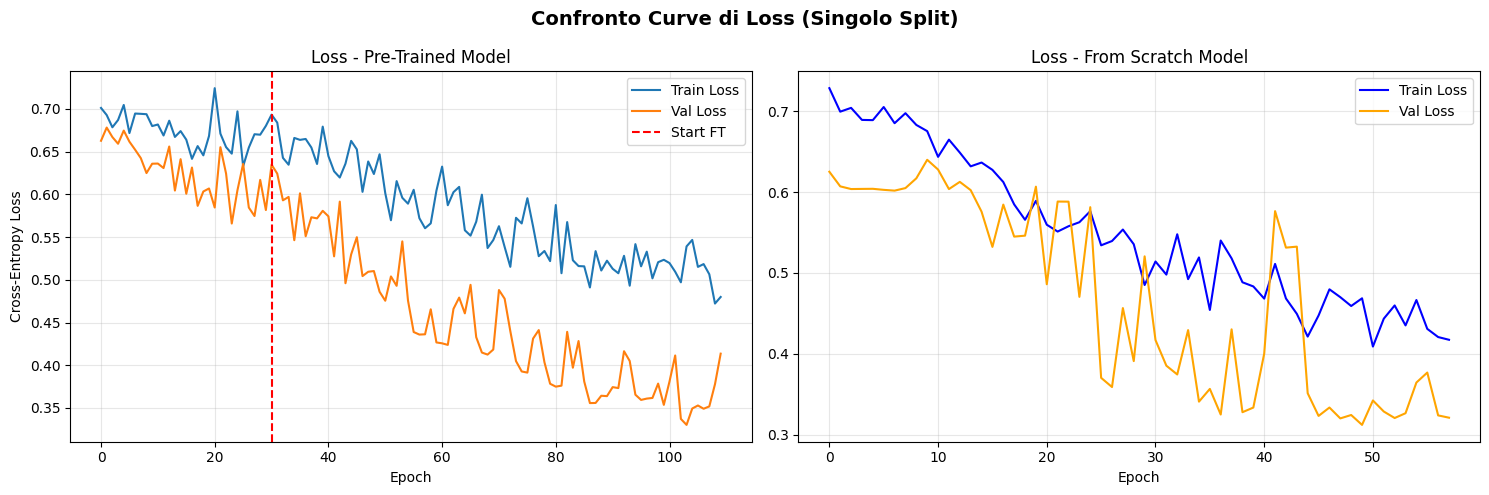

In [98]:
# ==============================================================
# TRAINING FROM SCRATCH (Singolo Split)
# ==============================================================
print("\n--- Training Modello From Scratch (No Pre-Training) ---")

# Creiamo un modello nuovo inizializzato casualmente, PIU' LEGGERO
# Riduciamo i layer (num_layers=1) e le teste di attenzione (nhead=2) per evitare overfitting
scratch_encoder = HybridCNNTransformer(input_length=SPECTRA_SIZE, d_model=64, num_layers=1, nhead=2)
model_scratch = HybridClassifierWrapper(scratch_encoder).to(device)

# Optimizer (no LP stage per from scratch, andiamo diretti di full FT)
optimizer_scr = AdamW(model_scratch.parameters(), lr=1e-4) # LR leggermente più alto per da zero
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler_scr = ReduceLROnPlateau(optimizer_scr, mode='min', factor=0.5, patience=7)

best_f1_scr = 0
no_improve_scr = 0
best_state_scr = None
history_scr = {"train_loss": [], "val_loss": []}

# Aumentate le epoche a 100
for epoch in range(100):
    model_scratch.train()
    total_loss = 0
    for Xb, yb in loader_tr:
        optimizer_scr.zero_grad()
        loss = criterion(model_scratch(Xb.to(device)), yb.to(device))
        loss.backward()
        optimizer_scr.step()
        total_loss += loss.item()

    preds_val, labels_val, probs_val, val_loss = eval_model(model_scratch, loader_va)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    history_scr["train_loss"].append(total_loss/len(loader_tr))
    history_scr["val_loss"].append(val_loss)

    # Step dello scheduler sulla val_loss
    scheduler_scr.step(val_loss)

    if val_f1 > best_f1_scr:
        best_f1_scr = val_f1
        best_state_scr = copy.deepcopy(model_scratch.state_dict())
        no_improve_scr = 0
    else:
        no_improve_scr += 1
        if no_improve_scr >= PATIENCE: # Usa la stessa PATIENCE = 25
            print(f"Early stopping at epoch {epoch+1}")
            break

model_scratch.load_state_dict(best_state_scr)
preds_test_scr, labels_test_scr, probs_test_scr, _ = eval_model(model_scratch, loader_te)

print("Risultati Test Set (From Scratch):")
print("Accuracy:", accuracy_score(labels_test_scr, preds_test_scr))
print("Macro-F1:", f1_score(labels_test_scr, preds_test_scr, average="macro"))
print("ROC-AUC:", roc_auc_score(labels_test_scr, probs_test_scr))

# ==============================================================
# PLOT LOSS CURVES CONFRONTO
# ==============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Pre-Trained Model (history viene dalla Cella 6)
if 'history' in globals():
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    if 'LP_EPOCHS' in globals():
        axes[0].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
    axes[0].set_title("Loss - Pre-Trained Model")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# 2. From Scratch Model
axes[1].plot(history_scr["train_loss"], label="Train Loss", color='blue')
axes[1].plot(history_scr["val_loss"], label="Val Loss", color='orange')
axes[1].set_title("Loss - From Scratch Model")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Confronto Curve di Loss (Singolo Split)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


--- Inizio 5-Fold CV con Modello From Scratch ---

Fold 1/5 (Scratch)
Fold 1 (Scratch) - Acc: 0.8478, Macro-F1: 0.8460, AUC: 0.9045


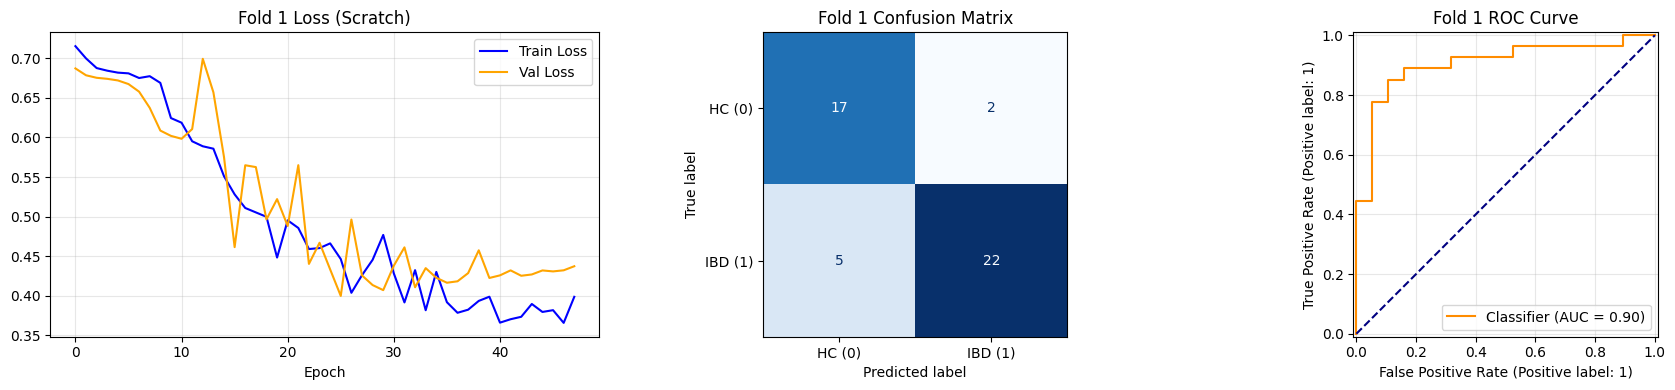


Fold 2/5 (Scratch)
Fold 2 (Scratch) - Acc: 0.8478, Macro-F1: 0.8442, AUC: 0.8713


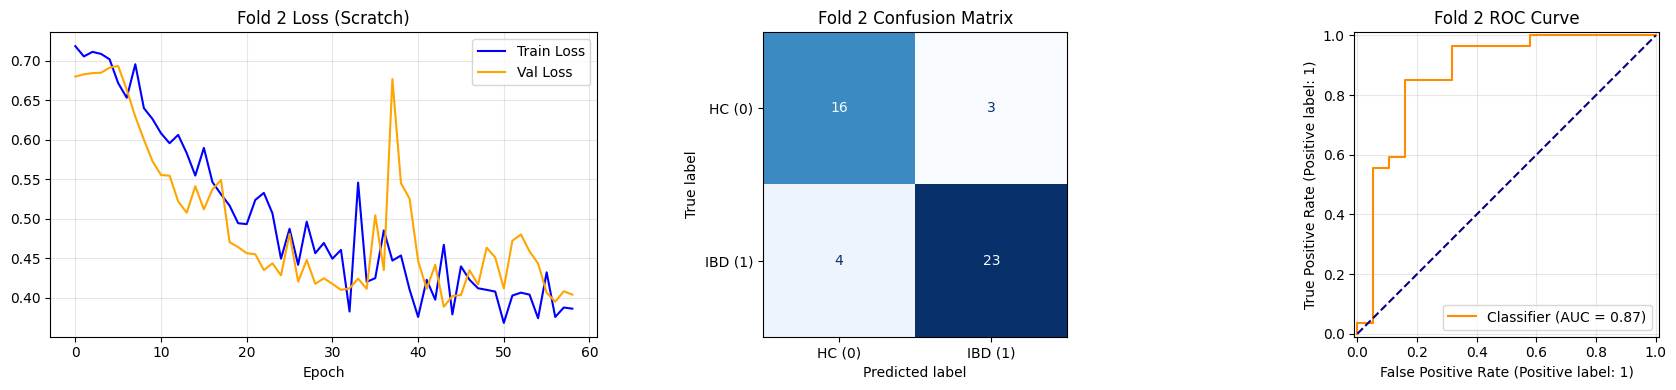


Fold 3/5 (Scratch)
Fold 3 (Scratch) - Acc: 0.9130, Macro-F1: 0.9067, AUC: 0.8811


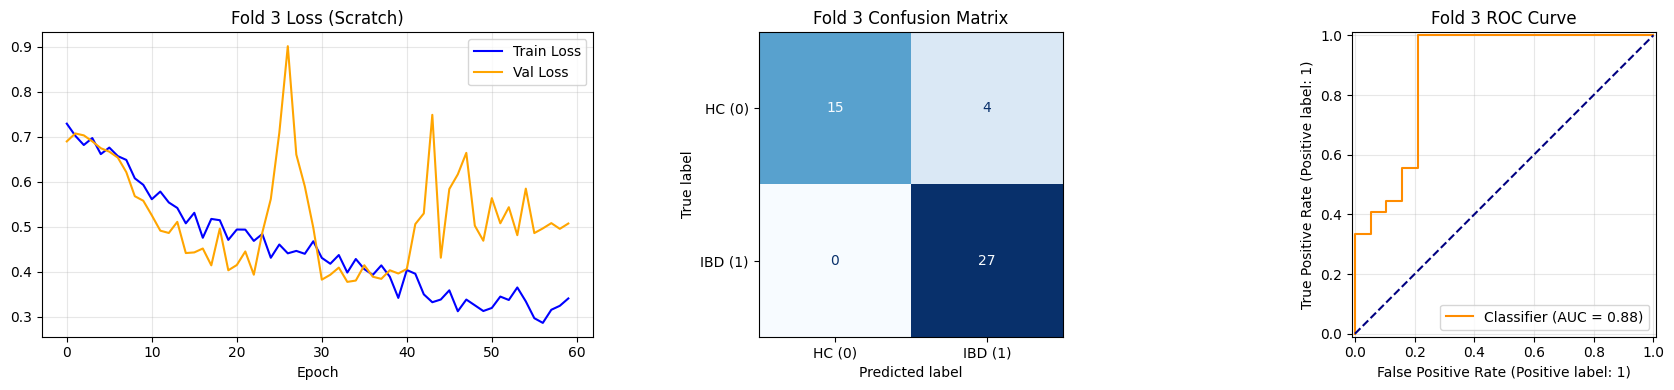


Fold 4/5 (Scratch)
Fold 4 (Scratch) - Acc: 0.8667, Macro-F1: 0.8634, AUC: 0.9053


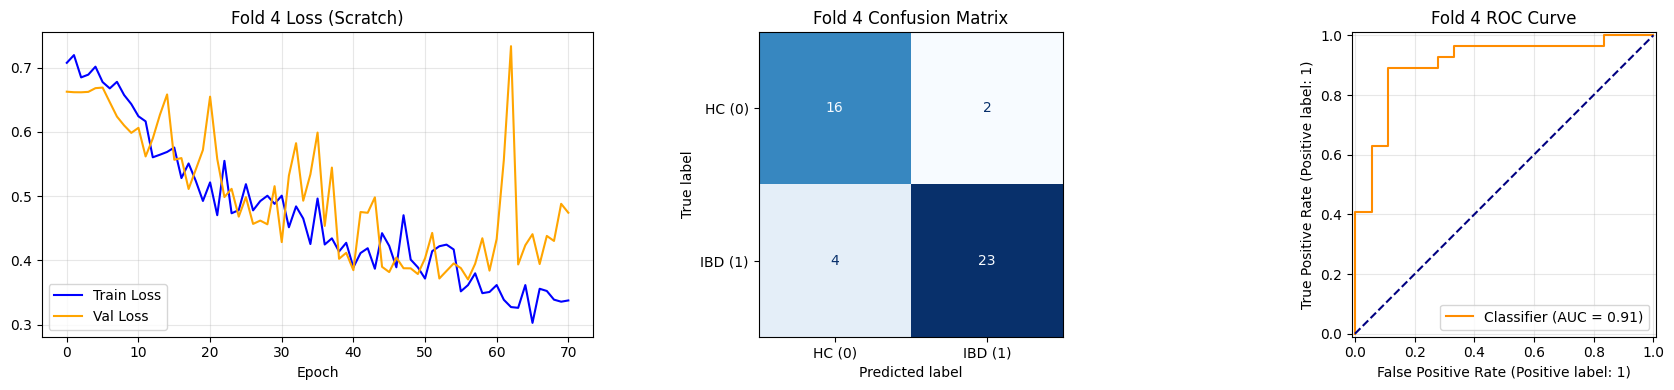


Fold 5/5 (Scratch)
Fold 5 (Scratch) - Acc: 0.8667, Macro-F1: 0.8611, AUC: 0.8807


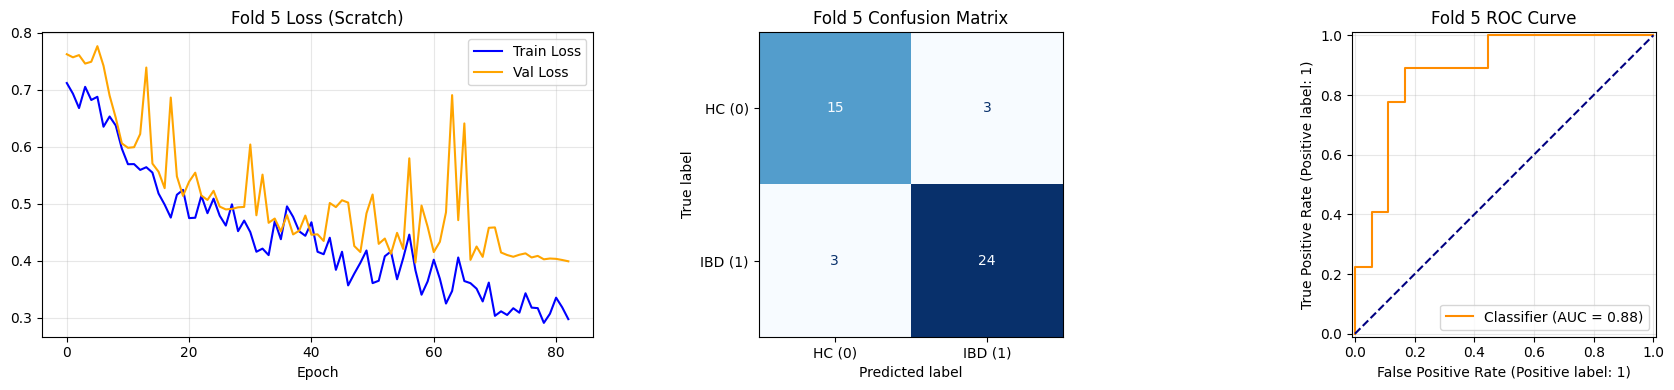


=== CONFRONTO FINALE K-FOLD ===
PRE-TRAINED:
  Accuracy: 0.7941 ± 0.0341
  Macro-F1: 0.7888 ± 0.0321
  ROC-AUC:  0.8125 ± 0.0293
FROM SCRATCH:
  Accuracy: 0.8684 ± 0.0239
  Macro-F1: 0.8643 ± 0.0226
  ROC-AUC:  0.8886 ± 0.0138


In [99]:
# ==============================================================
# K-FOLD CROSS-VALIDATION (FROM SCRATCH MODEL)
# ==============================================================
from torch.optim.lr_scheduler import ReduceLROnPlateau

fold_metrics_scr = {'acc': [], 'f1': [], 'auc': []}

print(f"\n--- Inizio {K_FOLDS}-Fold CV con Modello From Scratch ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, Y_data)):
    print(f"\n{'='*40}\nFold {fold+1}/{K_FOLDS} (Scratch)\n{'='*40}")

    Xtr_f = torch.from_numpy(X_data[train_idx]).unsqueeze(1).float()
    ytr_f = torch.from_numpy(Y_data[train_idx])
    Xva_f = torch.from_numpy(X_data[val_idx]).unsqueeze(1).float()
    yva_f = torch.from_numpy(Y_data[val_idx])

    # Usa il BATCH_SIZE aggiornato
    loader_tr_f = DataLoader(TensorDataset(Xtr_f, ytr_f), batch_size=BATCH_SIZE, shuffle=True)
    loader_va_f = DataLoader(TensorDataset(Xva_f, yva_f), batch_size=BATCH_SIZE, shuffle=False)

    # New Random Model for each fold (PIU' LEGGERO)
    scratch_encoder_cv = HybridCNNTransformer(input_length=SPECTRA_SIZE, d_model=64, num_layers=1, nhead=2)
    model_cv_scr = HybridClassifierWrapper(scratch_encoder_cv).to(device)

    ns = (ytr_f == 0).sum().item()
    ni = (ytr_f == 1).sum().item()
    w = torch.tensor([1.0/ns if ns>0 else 0, 1.0/ni if ni>0 else 0], device=device)
    criterion_cv = torch.nn.CrossEntropyLoss(weight=(w / w.sum() * 2.0))

    opt_scr_cv = AdamW(model_cv_scr.parameters(), lr=1e-4)
    scheduler_scr_cv = ReduceLROnPlateau(opt_scr_cv, mode='min', factor=0.5, patience=7)
    best_f1, no_improve, best_state = 0, 0, None

    fold_history_scr = {"train_loss": [], "val_loss": []}

    for epoch in range(FT_EPOCHS):
        model_cv_scr.train()
        train_loss = 0
        for Xb, yb in loader_tr_f:
            opt_scr_cv.zero_grad()
            loss = criterion_cv(model_cv_scr(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_scr_cv.step()
            train_loss += loss.item()

        preds_v, labels_v, probs_v, val_loss = eval_model(model_cv_scr, loader_va_f)
        v_f1 = f1_score(labels_v, preds_v, average="macro")

        fold_history_scr["train_loss"].append(train_loss / len(loader_tr_f))
        fold_history_scr["val_loss"].append(val_loss)

        # Scheduler step
        scheduler_scr_cv.step(val_loss)

        if v_f1 > best_f1:
            best_f1 = v_f1
            best_state = copy.deepcopy(model_cv_scr.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE: break

    model_cv_scr.load_state_dict(best_state)
    preds_v, labels_v, probs_v, _ = eval_model(model_cv_scr, loader_va_f)

    acc = accuracy_score(labels_v, preds_v)
    f1 = f1_score(labels_v, preds_v, average="macro")
    auc = roc_auc_score(labels_v, probs_v)

    fold_metrics_scr['acc'].append(acc)
    fold_metrics_scr['f1'].append(f1)
    fold_metrics_scr['auc'].append(auc)
    print(f"Fold {fold+1} (Scratch) - Acc: {acc:.4f}, Macro-F1: {f1:.4f}, AUC: {auc:.4f}")

    # --- PLOTTING PER FOLD ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    # 1. Loss Curve
    ax1.plot(fold_history_scr["train_loss"], label="Train Loss", color='blue')
    ax1.plot(fold_history_scr["val_loss"], label="Val Loss", color='orange')
    ax1.set_title(f"Fold {fold+1} Loss (Scratch)")
    ax1.set_xlabel("Epoch")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Confusion Matrix
    cm = confusion_matrix(labels_v, preds_v)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC (0)', 'IBD (1)'])
    disp.plot(cmap='Blues', ax=ax2, colorbar=False)
    ax2.set_title(f"Fold {fold+1} Confusion Matrix")

    # 3. ROC Curve
    RocCurveDisplay.from_predictions(labels_v, probs_v, ax=ax3, color='darkorange')
    ax3.plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax3.set_title(f"Fold {fold+1} ROC Curve")
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n=== CONFRONTO FINALE K-FOLD ===")
print("PRE-TRAINED:")
print(f"  Accuracy: {np.mean(fold_metrics_pt['acc']):.4f} \u00b1 {np.std(fold_metrics_pt['acc']):.4f}")
print(f"  Macro-F1: {np.mean(fold_metrics_pt['f1']):.4f} \u00b1 {np.std(fold_metrics_pt['f1']):.4f}")
print(f"  ROC-AUC:  {np.mean(fold_metrics_pt['auc']):.4f} \u00b1 {np.std(fold_metrics_pt['auc']):.4f}")
print("FROM SCRATCH:")
print(f"  Accuracy: {np.mean(fold_metrics_scr['acc']):.4f} \u00b1 {np.std(fold_metrics_scr['acc']):.4f}")
print(f"  Macro-F1: {np.mean(fold_metrics_scr['f1']):.4f} \u00b1 {np.std(fold_metrics_scr['f1']):.4f}")
print(f"  ROC-AUC:  {np.mean(fold_metrics_scr['auc']):.4f} \u00b1 {np.std(fold_metrics_scr['auc']):.4f}")